In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

#seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

#mpl
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors

In [7]:
#Read in 5-membered hetaryne data

#script is located in cwd
histo_path = Path.cwd()

#mod8 path is one above
mod8_path = histo_path.parent #get the path above this current dir

#tld is one above mod8
project_dir = mod8_path.parent

#data is located in the mod7 dir
five_path = project_dir / "Module7_Extract_DFT_Molecular_Descriptors" / "5_membered_Calculated_Molecular_Descriptors.csv"
five_dehydrog_df = pd.read_csv(five_path)

#print some diag
print(f"{five_path.name} contants {len(five_dehydrog_df)} 5-membered hetarynes:\n")

#sanity check
five_dehydrog_df.head()

5_membered_Calculated_Molecular_Descriptors.csv contants 1468 5-membered hetarynes:



,arene_ID,arene_smiles,arene_energy,aryne_ID,aryne_smiles,aryne_energy,dehydrogenation_energy,Sz_Aryne_Ring,RingSys_Type,Aryne_Aindx_1,...,Max_angle_dev,Sum_abs_dev,Aryne_DiH_Ang,eHOMO(eV),eLUMO(eV),H_L_Gap(eV),Hirsh_chgs_Aindx_1,Hirsh_chgs_Aindx_2,Sum_Abs_Hirsh_aryne,Abs_Dif_Bnd_Angl
0,arene_1,O=c1nc2ccsc2cs1,-1156.0883,aryne_1,O=c1nc2c#csc2cs1,-1154.7269,124.0423,5,multi,4,...,17.4185,20.9698,0.091,-8.2033,-3.1162,5.0871,0.0001,-0.0688,0.0689,13.8672
1,arene_16,c1c[nH]nn1,-241.9423,aryne_17,c1nn[nH]c#1,-240.5255,158.8063,5,mono,4,...,21.8453,40.2947,0.046,-9.2856,-3.3609,5.9247,-0.1557,0.1634,0.3191,40.2947
2,arene_30,O=c1ccn2c(=O)[nH]ccn12,-545.7148,aryne_33,O=c1[nH]ccn2c(=O)c#cn12,-544.3235,142.8048,5,multi,8,...,6.8214,9.6764,6.498,-7.5361,-3.2572,4.2789,-0.0603,0.0185,0.0788,3.9664
3,arene_38,O=c1cnc2nccn2o1,-506.3813,aryne_42,O=c1cnc2nc#cn2o1,-504.9847,146.1306,5,multi,6,...,24.8400,42.2232,0.057,-8.8042,-3.3330,5.4712,0.1627,-0.1413,0.3040,42.2232
4,arene_42,O=c1ccc2occc2o1,-494.2334,aryne_47,O=c1ccc2oc#cc2o1,-492.8235,154.4765,5,multi,6,...,21.1984,32.8263,0.052,-8.0099,-3.5878,4.4221,0.1295,-0.1182,0.2477,32.8263


In [8]:
# Read in 6-membered hetaryne data

#data is located in the mod7 dir
six_path = project_dir / "Module7_Extract_DFT_Molecular_Descriptors" / "6_membered_Calculated_Molecular_Descriptors.csv"
six_dehydrog_df = pd.read_csv(six_path)

#print some diag
print(f"{six_path.name} contants {len(six_dehydrog_df)} 6-membered hetarynes:\n")

#sanity check
six_dehydrog_df.head()

6_membered_Calculated_Molecular_Descriptors.csv contants 6648 6-membered hetarynes:



,arene_ID,arene_smiles,arene_energy,aryne_ID,aryne_smiles,aryne_energy,dehydrogenation_energy,Sz_Aryne_Ring,RingSys_Type,Aryne_Aindx_1,...,Max_angle_dev,Sum_abs_dev,Aryne_DiH_Ang,eHOMO(eV),eLUMO(eV),H_L_Gap(eV),Hirsh_chgs_Aindx_1,Hirsh_chgs_Aindx_2,Sum_Abs_Hirsh_aryne,Abs_Dif_Bnd_Angl
0,arene_2,c1csn2nn[nH]cc-2o1,-846.4294,aryne_2,c1oc2c[nH]nnn-2sc#1,-845.1003,103.7738,6,multi,9,...,28.1870,32.3229,9.361,-7.5885,-1.8409,5.7476,-0.1534,0.0712,0.2246,32.3229
1,arene_3,O=c1cnc2occsc=2c1=O,-946.3140,aryne_3,O=c1cnc2oc#csc=2c1=O,-944.9744,110.3626,6,multi,6,...,27.9700,28.5260,0.049,-7.6077,-3.6957,3.9120,0.0756,-0.1217,0.1973,27.4140
2,arene_4,O=c1cnc2sc(=O)ccc2s1,-1269.2819,aryne_4,O=c1c#cc2sc(=O)cnc2s1,-1267.9693,93.4199,6,multi,2,...,16.0394,29.2699,0.582,-8.2904,-2.7467,5.5437,-0.0285,-0.0286,0.0571,2.8089
3,arene_5,O=c1ccn2sccsn2[nH]1,-1228.5052,aryne_5,O=c1c#cn2sccsn2[nH]1,-1227.1702,107.4761,6,multi,2,...,11.5546,15.8775,28.895,-7.5024,-1.8204,5.6820,-0.1116,0.0126,0.1242,15.8775
4,arene_7,O=c1ncn2cnccn2c1=O,-599.7472,aryne_8,O=c1ncn2cnc#cn2c1=O,-598.3859,123.9795,6,multi,7,...,22.9304,28.4099,0.193,-7.9336,-2.5449,5.3887,0.0734,-0.0427,0.1161,28.4099


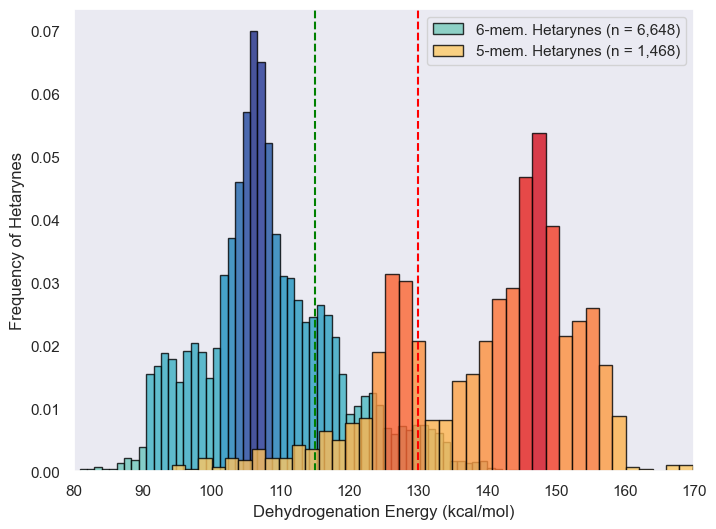

In [10]:
#6-membered dehydrog. energies
six_dehyd_data = six_dehydrog_df["dehydrogenation_energy"]

#5-membered dehydrog. energies"
five_dehyd_data = five_dehydrog_df["dehydrogenation_energy"]

fig, ax = plt.subplots(figsize=(8,6))

#colormaps
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

#six-membered hetarynes
m, bins, patches = ax.hist(six_dehyd_data, bins=120, density=True, edgecolor='black', label='6-mem. Hetarynes (n = 6,648)', alpha=0.8)
# To normalize your values
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#five-membered hetarynes
n, bins, patches = ax.hist(five_dehyd_data, bins=40, density=True, edgecolor='black', label='5-mem. Hetarynes (n = 1,468)', alpha=0.8)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

plt.xlim(80,170)
plt.axvline(x=115, color='green', linestyle='--')
plt.axvline(x=130, color='red', linestyle='--')
ax.set(xlabel='Dehydrogenation Energy (kcal/mol)')
ax.set(ylabel='Frequency of Hetarynes')
ax.legend()

# #save the figure, locally.
plt.savefig('dehydrogenation_energy_histogram_by_ring_size.png', bbox_inches="tight", transparent=True)

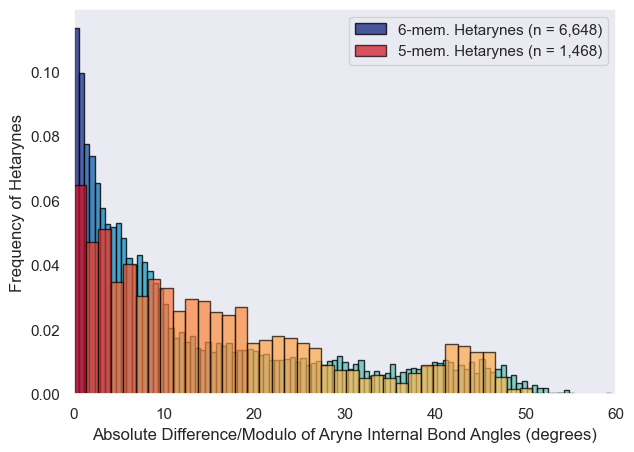

In [11]:
#6-membered dehydrog. energies
six_dehyd_data = six_dehydrog_df["Abs_Dif_Bnd_Angl"]

#5-membered dehydrog. energies"
five_dehyd_data = five_dehydrog_df["Abs_Dif_Bnd_Angl"]

fig, ax = plt.subplots(figsize=(7,5))

#colormaps
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

#six-membered hetarynes
m, bins, patches = ax.hist(six_dehyd_data, bins=120, density=True, edgecolor='black', label='6-mem. Hetarynes (n = 6,648)', alpha=0.8)
# To normalize your values
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#five-membered hetarynes
n, bins, patches = ax.hist(five_dehyd_data, bins=40, density=True, edgecolor='black', label='5-mem. Hetarynes (n = 1,468)', alpha=0.7)
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

plt.xlim(0,60)
plt.axvline(x=115, color='green', linestyle='--')
plt.axvline(x=130, color='red', linestyle='--')
ax.set(xlabel='Absolute Difference/Modulo of Aryne Internal Bond Angles (degrees)')
ax.set(ylabel='Frequency of Hetarynes')
ax.legend()

# #save the figure, locally.
plt.savefig('modulo_bond_angles_histogram_by_ring_size.png', bbox_inches="tight", transparent=True)